# Asioinnin Heatmap - kauppa_osasto.jpg
Tässä muistikirjassa piirretään asiakasvirtojen "Heatmap" kaupan pohjapiirroksen päälle. 
Nyt lämpökartta on rajattu tiukasti osastojen sisälle, ja lisäksi siitä on **leikattu kokonaan irti `dead_zones` (kuten lovi, varastot ja lastausalue)**, jotka risteävät osastojen kanssa!
Lisäksi väriskaalaa on säädetty siten, että todella kuumat osastot (kuten Liha/Kala) eivät ylikorostu täysin punaisiksi laatoiksi, vaan niiden sisäinen dynamiikka jää näkyviin.

In [160]:
import sys
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from config.store_config import store_config

profile = store_config["geometry"]["map_profiles"]["osasto"]

scale = profile["scale_cm_per_px"]
origin_x = profile["origin_x_px"]
origin_y = profile["origin_y_px"]
width = profile["width_px"]
height = profile["height_px"]

img_x_min = -origin_x * scale
img_x_max = (width - origin_x) * scale
img_y_min = -origin_y * scale
img_y_max = (height - origin_y) * scale


In [161]:
con = duckdb.connect(':memory:')

# Ladataan KAIKKI puhdistettu data (100% otos) validien asiointien heatmapia varten.
# Tämä yhdistää kaikkien puhdistetussa datassa olevien asiakkaiden liikkeet.
query = f"""
SELECT x, y 
FROM read_parquet('../data/processed/*.parquet')
WHERE x BETWEEN {img_x_min} AND {img_x_max} 
  AND y BETWEEN {img_y_min} AND {img_y_max}
"""

df = con.execute(query).df()
print(f"Ladattu {len(df)} havaintopistettä kaikista valideista asioinneista.")


Ladattu 12154222 havaintopistettä kaikista valideista asioinneista.


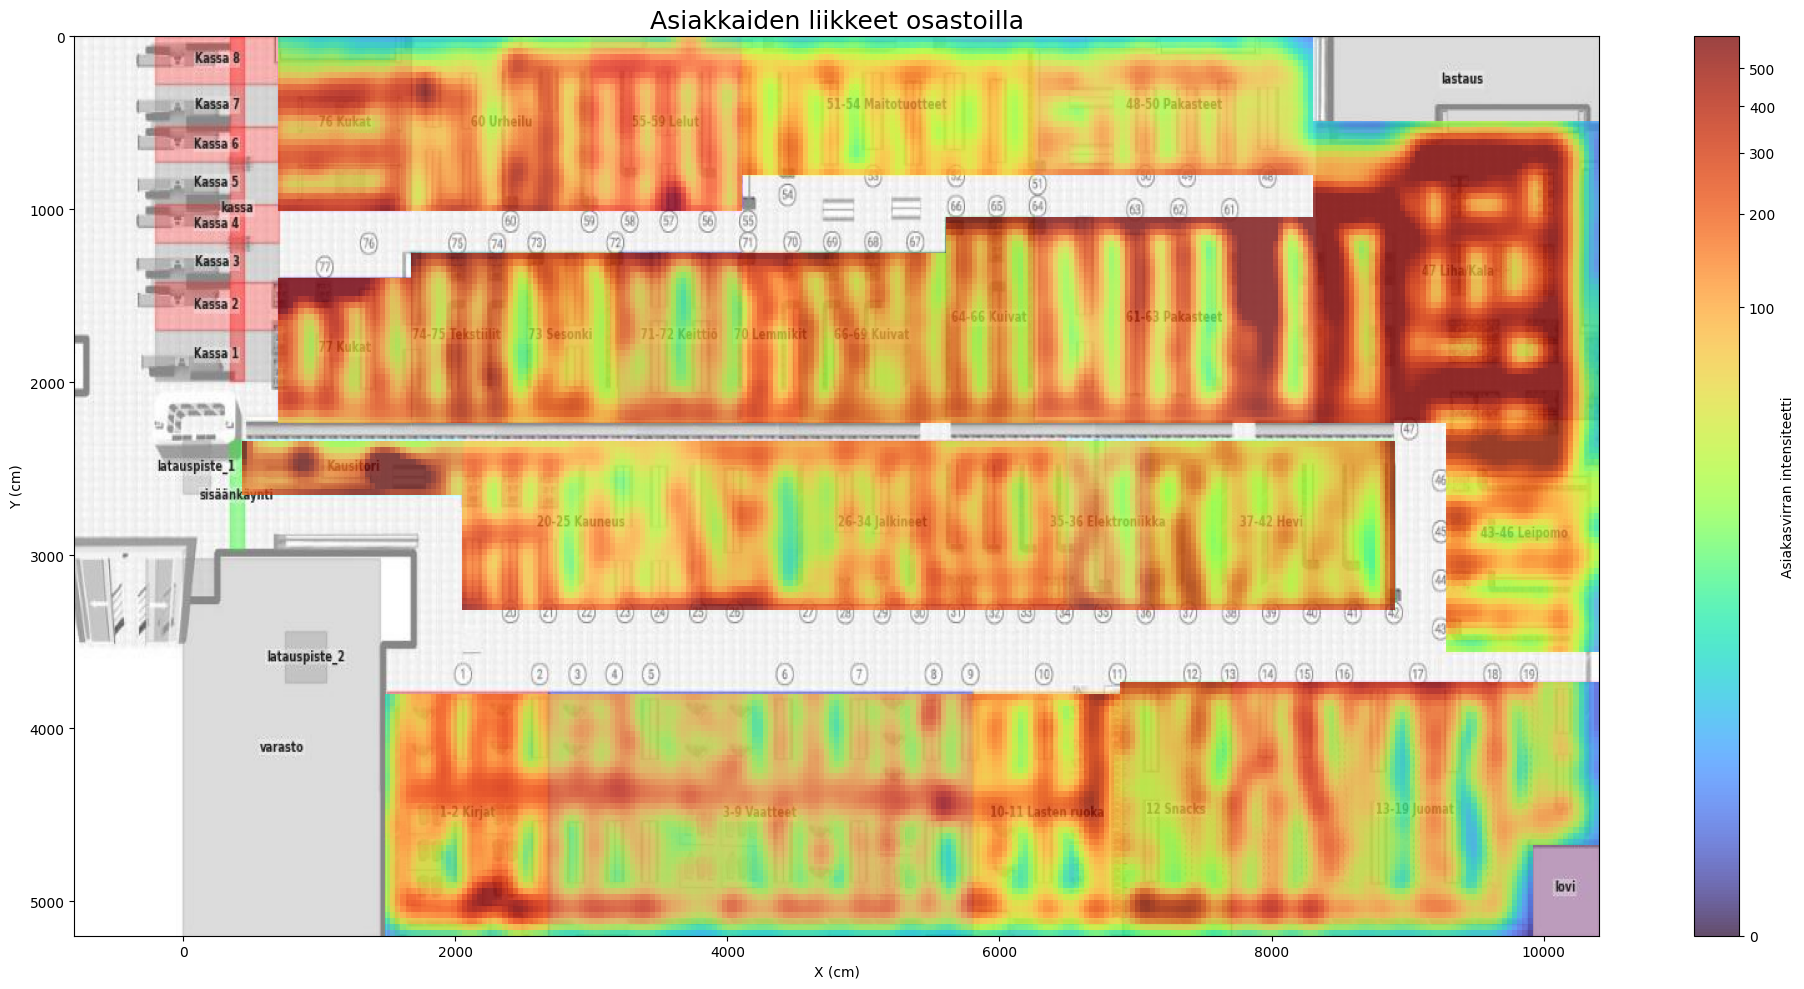

In [162]:
import matplotlib.colors as mcolors
import numpy as np
from scipy.ndimage import gaussian_filter
import copy
import matplotlib.patches as patches

img_path = '../kauppa_osasto.jpg'
img = Image.open(img_path)

fig, ax = plt.subplots(figsize=(20, 10))

extent = [img_x_min, img_x_max, img_y_max, img_y_min]
ax.imshow(img, extent=extent, aspect='auto', alpha=0.9)

# 1. Lasketaan matriisi
bins_x = np.linspace(img_x_min, img_x_max, 300)
bins_y = np.linspace(img_y_min, img_y_max, 150)
heatmap, xedges, yedges = np.histogram2d(df['x'], df['y'], bins=[bins_x, bins_y])

# 2. Pehmennetään data
sigma_value = 1.5
heatmap_smooth = gaussian_filter(heatmap, sigma=sigma_value)

# 3. LUODAAN MASKI OSASTOISTA JA POISTETAAN DEAD ZONES
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2
X, Y = np.meshgrid(x_centers, y_centers, indexing='ij')

mask = np.zeros_like(X, dtype=bool)
departments = store_config["spatial_zones"]["departments"]

# Lisätään kaikki osastot maskiin (True)
for dept_name, dept_data in departments.items():
    xmin, xmax, ymin, ymax = dept_data["coords"]
    dept_mask = (X >= xmin) & (X <= xmax) & (Y >= ymin) & (Y <= ymax)
    mask = mask | dept_mask

# POISTETAAN dead_zones (pakotetaan False)
# Tämä poistaa 'lovin' Juomat-osaston nurkasta sekä varastot, vaikka ne risteäisivät osastojen kanssa!
dead_zones = store_config["spatial_zones"]["dead_zones"]
for dz_name, dz_coords in dead_zones.items():
    xmin, xmax, ymin, ymax = dz_coords
    dz_mask = (X >= xmin) & (X <= xmax) & (Y >= ymin) & (Y <= ymax)
    mask = mask & (~dz_mask)

# Piilotetaan maskin ulkopuoliset alueet (NaN)
heatmap_smooth[~mask] = np.nan

# 4. Väriskaalan palautus maltillisemmaksi
# Nostetaan leikkausrajaa 88 -> 93 persentiiliin ja gammaa 0.6 -> 0.7.
# Tämä antaa Liha/Kala -osastolle enemmän "headroomia", 
# jolloin koko osasto ei pala puhki yhtenäiseksi punaiseksi laatikoksi, 
# vaan sen sisäiset lämpötilaerot näkyvät taas hienosti.
active_areas = heatmap_smooth[mask & (heatmap_smooth > 0.1)]
max_color_limit = np.nanpercentile(active_areas, 97) if len(active_areas) > 0 else 1

cmap = copy.copy(plt.get_cmap('turbo'))
cmap.set_bad(alpha=0)

im = ax.imshow(
    heatmap_smooth.T, 
    extent=extent, 
    cmap=cmap, 
    alpha=0.75, 
    aspect='auto',
    norm=mcolors.PowerNorm(gamma=0.2, vmin=0, vmax=max_color_limit),
    zorder=2
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Asiakasvirran intensiteetti')

plt.title('Asiakkaiden liikkeet osastoilla', fontsize=18)
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')

plt.xlim(img_x_min, img_x_max)
plt.ylim(img_y_max, img_y_min)

plt.tight_layout()
plt.show()
